In [22]:
import cv2
import torch
import os
import xml.etree.ElementTree as ET

image_dir = "../../Data/JPEGImages"
annotation_dir = "../../Data/Annotations"

images = []
boxes = []
labels = []

for name in os.listdir(image_dir):

    if not name.endswith(".jpg"):
        continue

    xml_path = os.path.join(
        annotation_dir,
        name.replace(".jpg", ".xml")
    )

    root = ET.parse(xml_path).getroot()

    image_boxes = []

    for obj in root.findall("object"):

        label = obj.find("name").text

        if label != "person":
            continue

        box = obj.find("bndbox")

        xmin = int(float(box.find("xmin").text))
        ymin = int(float(box.find("ymin").text))
        xmax = int(float(box.find("xmax").text))
        ymax = int(float(box.find("ymax").text))
        
        image_boxes.append([xmin, ymin, xmax, ymax])

    if len(image_boxes) > 0:
        image = cv2.imread(
            os.path.join(image_dir, name)
        )

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        images.append(torch.tensor(image))
        boxes.append(torch.tensor(image_boxes))
        labels.append(["person"] * len(image_boxes))

print(len(images))
print(images[0].shape)
print(boxes[0])
print(labels[0])

9583
torch.Size([500, 486, 3])
tensor([[174, 101, 349, 351]])
['person']


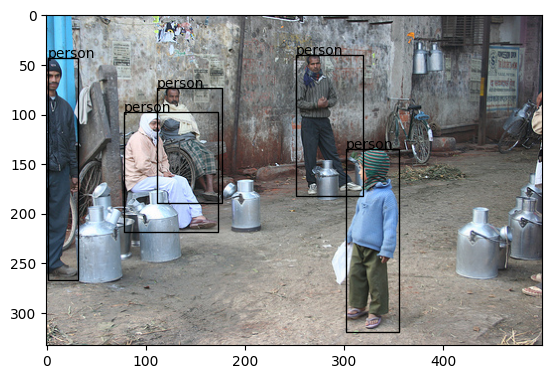

In [31]:
import matplotlib.pyplot as plt

plt.imshow(images[400])

for box, label in zip(boxes[400], labels[400]):

    xmin, ymin, xmax, ymax = box

    plt.gca().add_patch(
        plt.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False
        )
    )

    plt.text(xmin, ymin, label)

plt.show()